In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, StandardScaler
from sklearn.model_selection import cross_val_score, train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import joblib as jb

import warnings
warnings.filterwarnings('ignore')

In [3]:
df = pd.read_csv('personality_dataset.csv')
df.head()

,Time_spent_Alone,Stage_fear,Social_event_attendance,Going_outside,Drained_after_socializing,Friends_circle_size,Post_frequency,Personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert


In [4]:
df.shape

(2900, 8)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2900 entries, 0 to 2899
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Time_spent_Alone           2837 non-null   float64
 1   Stage_fear                 2827 non-null   str    
 2   Social_event_attendance    2838 non-null   float64
 3   Going_outside              2834 non-null   float64
 4   Drained_after_socializing  2848 non-null   str    
 5   Friends_circle_size        2823 non-null   float64
 6   Post_frequency             2835 non-null   float64
 7   Personality                2900 non-null   str    
dtypes: float64(5), str(3)
memory usage: 181.4 KB


In [6]:
df.columns = df.columns.str.lower().str.strip()

In [7]:
df.describe()

,time_spent_alone,social_event_attendance,going_outside,friends_circle_size,post_frequency
count,2837.000000,2838.000000,2834.000000,2823.000000,2835.000000
mean,4.505816,3.963354,3.000000,6.268863,3.564727
std,3.479192,2.903827,2.247327,4.289693,2.926582
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,2.000000,1.000000,3.000000,1.000000
50%,4.000000,3.000000,3.000000,5.000000,3.000000
75%,8.000000,6.000000,5.000000,10.000000,6.000000
max,11.000000,10.000000,7.000000,15.000000,10.000000


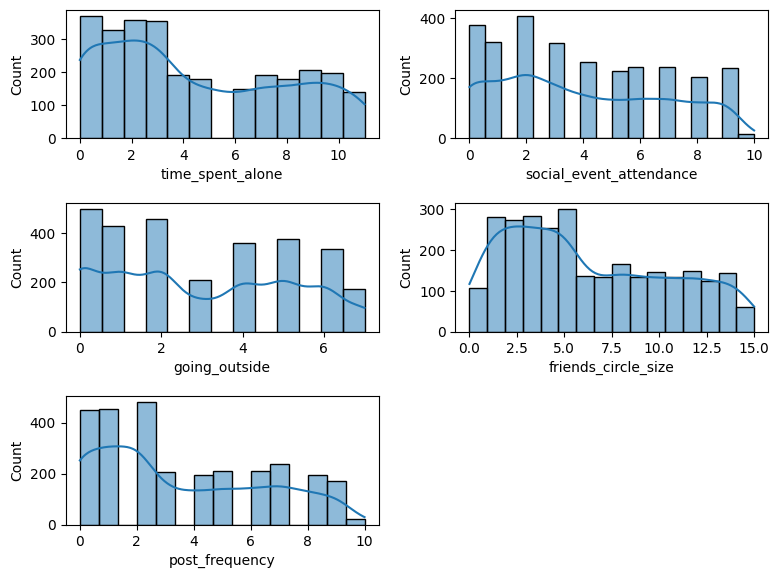

In [8]:
plt.figure(figsize=(8, 6))
plt.subplot(3, 2, 1)
sns.histplot(df['time_spent_alone'], kde=True)

plt.subplot(3, 2, 2)
sns.histplot(df['social_event_attendance'], kde=True)

plt.subplot(3, 2, 3)
sns.histplot(df['going_outside'], kde=True)

plt.subplot(3, 2, 4)
sns.histplot(df['friends_circle_size'], kde=True)

plt.subplot(3, 2, 5)
sns.histplot(df['post_frequency'], kde=True)

plt.tight_layout(pad=1.5);

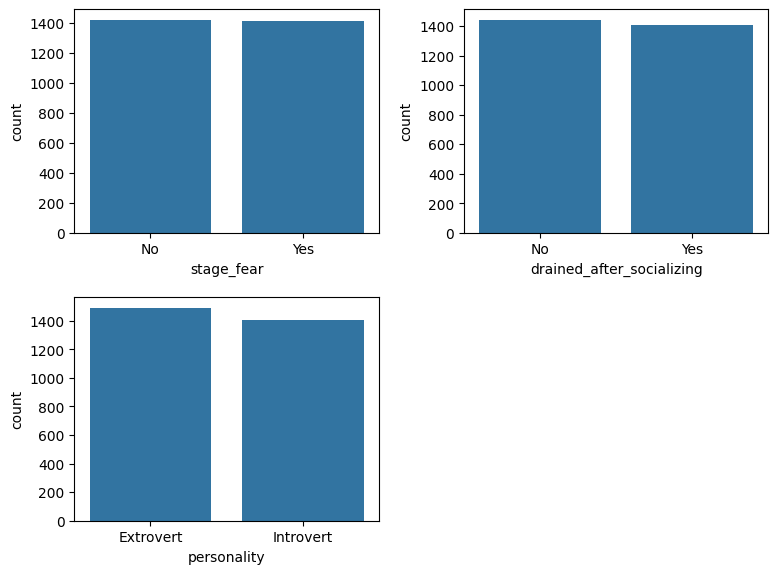

In [9]:
plt.figure(figsize=(8, 6))
plt.subplot(2, 2, 1)
sns.countplot(x=df['stage_fear'])

plt.subplot(2, 2, 2)
sns.countplot(x=df['drained_after_socializing'])

plt.subplot(2, 2, 3)
sns.countplot(x=df['personality'])

plt.tight_layout(pad=1.5);

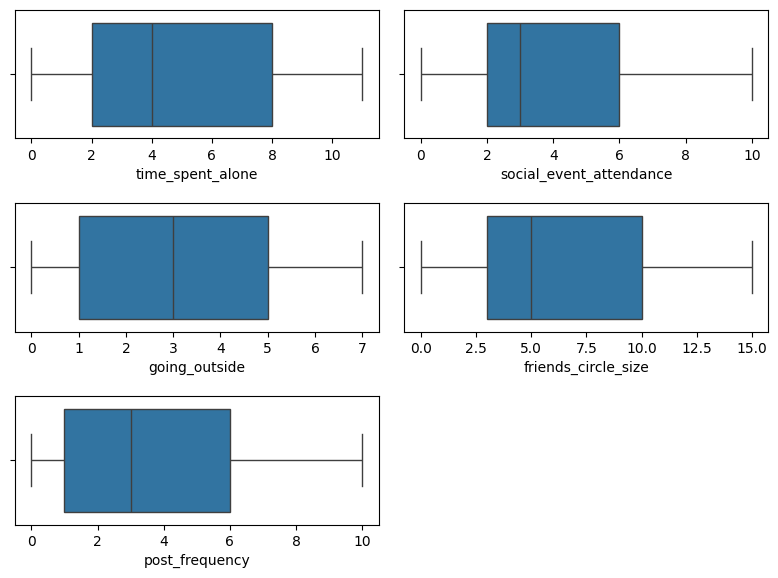

In [10]:
plt.figure(figsize=(8, 6))
plt.subplot(3, 2, 1)
sns.boxplot(x=df['time_spent_alone'])

plt.subplot(3, 2, 2)
sns.boxplot(x=df['social_event_attendance'])

plt.subplot(3, 2, 3)
sns.boxplot(x=df['going_outside'])

plt.subplot(3, 2, 4)
sns.boxplot(x=df['friends_circle_size'])

plt.subplot(3, 2, 5)
sns.boxplot(x=df['post_frequency'])

plt.tight_layout(pad=1.5);

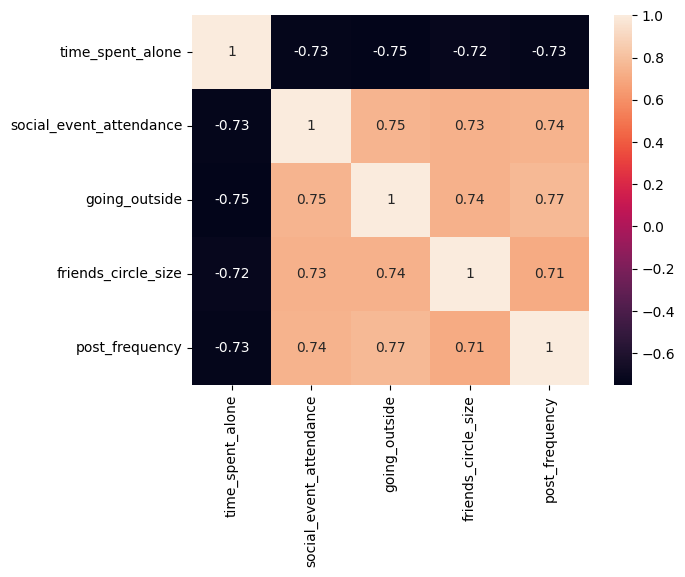

In [11]:
sns.heatmap(df.corr(numeric_only=True), annot=True);

In [12]:
df.tail()

,time_spent_alone,stage_fear,social_event_attendance,going_outside,drained_after_socializing,friends_circle_size,post_frequency,personality
2895,3.0,No,7.0,6.0,No,6.0,6.0,Extrovert
2896,3.0,No,8.0,3.0,No,14.0,9.0,Extrovert
2897,4.0,Yes,1.0,1.0,Yes,4.0,0.0,Introvert
2898,11.0,Yes,1.0,NaN,Yes,2.0,0.0,Introvert
2899,3.0,No,6.0,6.0,No,6.0,9.0,Extrovert


In [13]:
cleaned_df = df.copy()
cleaned_df.head()

,time_spent_alone,stage_fear,social_event_attendance,going_outside,drained_after_socializing,friends_circle_size,post_frequency,personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert


In [14]:
(cleaned_df.isnull().sum()) / cleaned_df.shape[0]

time_spent_alone             0.021724
stage_fear                   0.025172
social_event_attendance      0.021379
going_outside                0.022759
drained_after_socializing    0.017931
friends_circle_size          0.026552
post_frequency               0.022414
personality                  0.000000
dtype: float64

In [15]:
cleaned_df.duplicated().sum()

np.int64(388)

In [16]:
cleaned_df.drop_duplicates(inplace=True)

In [17]:
cleaned_df.head()

,time_spent_alone,stage_fear,social_event_attendance,going_outside,drained_after_socializing,friends_circle_size,post_frequency,personality
0,4.0,No,4.0,6.0,No,13.0,5.0,Extrovert
1,9.0,Yes,0.0,0.0,Yes,0.0,3.0,Introvert
2,9.0,Yes,1.0,2.0,Yes,5.0,2.0,Introvert
3,0.0,No,6.0,7.0,No,14.0,8.0,Extrovert
4,3.0,No,9.0,4.0,No,8.0,5.0,Extrovert


In [19]:
X = cleaned_df.drop(columns='personality')
y = cleaned_df['personality']

In [21]:
xTrain, xTest, yTrain, yTest = train_test_split(X, y, test_size=0.25, random_state=42)

In [47]:
le = LabelEncoder()
yTrain = le.fit_transform(y=yTrain)
yTest = le.transform(yTest)

In [48]:
df.isnull().sum()

time_spent_alone             63
stage_fear                   73
social_event_attendance      62
going_outside                66
drained_after_socializing    52
friends_circle_size          77
post_frequency               65
personality                   0
dtype: int64

In [49]:
from sklearn.impute import SimpleImputer


pipeline = Pipeline([
      ("Preprocess", ColumnTransformer(
            transformers = [
                  ("cate_columns", Pipeline([
                        ('cate_impute', SimpleImputer(strategy="most_frequent")),
                        ('encoder', OrdinalEncoder())
                  ]), [1, 4]),
                  ("numeric_col", Pipeline([
                        ("numeric_imputer", SimpleImputer(strategy="mean")),
                        ("scale", StandardScaler())
                  ]), [0, 2, 3, 5, 6])
            ],
            remainder='passthrough'
      ))
])

In [50]:
pipeline

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('Preprocess', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cate_columns', ...), ('numeric_col', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transform

In [51]:
xTrain = pipeline.fit_transform(xTrain)
xTest = pipeline.transform(xTest)

In [52]:
model_selection = {
    'Logistic Regression': LogisticRegression(),
    'K-Neighbors Classifier': KNeighborsClassifier(),
    'Naive Bayes': GaussianNB(),
    'Decision Tree Classifier': DecisionTreeClassifier(),
    'Support Vector Machine': SVC()
}

In [53]:
for name, model in model_selection.items():
    score = cross_val_score(model, xTrain, yTrain, cv=5)
    print(f"{name} Accuracy score is: {score.mean():.4f}")

Logistic Regression Accuracy score is: 0.9140
K-Neighbors Classifier Accuracy score is: 0.9161
Naive Bayes Accuracy score is: 0.9267
Decision Tree Classifier Accuracy score is: 0.8445
Support Vector Machine Accuracy score is: 0.9267


In [54]:
params_model = {
    'Naive Bayes': GaussianNB(),
    'Support Vector Machine': SVC()
}

In [55]:
params_grid = {
    'Naive Bayes': {
        'var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
    }, 
    'Support Vector Machine': {
        'C': [1, 10, 20, 30],
        'kernel': ['rbf', 'linear'],
        'gamma': ['scale', 'auto']
    }
}

In [56]:
for name in params_model:
    grid = GridSearchCV(params_model[name], params_grid[name], cv=5, return_train_score=False, scoring='accuracy')
    grid.fit(xTrain, yTrain)

    print('Best estimator: ', grid.best_estimator_)
    print('Best score: ', grid.best_score_)
    print('Best parameter', grid.best_params_)

Best estimator:  GaussianNB()
Best score:  0.9267481234832665
Best parameter {'var_smoothing': 1e-09}
Best estimator:  SVC(C=1)
Best score:  0.9267481234832665
Best parameter {'C': 1, 'gamma': 'scale', 'kernel': 'rbf'}


In [57]:
xgb_model = XGBClassifier(use_label_encoder=False, eval_metrix='mlogloss')

parameter = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

In [58]:
grid_search = GridSearchCV(xgb_model, parameter, scoring='accuracy', cv=5, return_train_score=False)
grid_search.fit(xTrain, yTrain)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","XGBClassifier...obs=None, ...)"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [50, 100, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each f

In [60]:
grid_search.best_params_

{'colsample_bytree': 0.8,
 'learning_rate': 0.01,
 'max_depth': 3,
 'n_estimators': 50,
 'subsample': 0.8}

In [61]:
y_pred = grid_search.predict(xTest)

In [62]:
accuracy_score(yTest, y_pred)

0.928343949044586

In [64]:
from sklearn.metrics import classification_report

print("\n", classification_report(yTest, y_pred))


               precision    recall  f1-score   support

           0       0.95      0.93      0.94       360
           1       0.91      0.93      0.92       268

    accuracy                           0.93       628
   macro avg       0.93      0.93      0.93       628
weighted avg       0.93      0.93      0.93       628



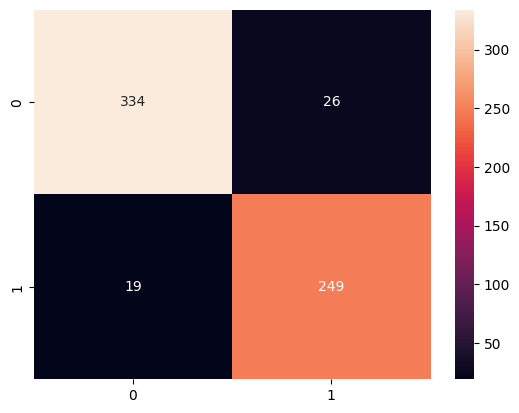

In [65]:
sns.heatmap(confusion_matrix(yTest, y_pred), annot=True, fmt='d');